# **Libraries**

In [185]:
%run ../../../setup_workspace.py # ../ means level up 

# **Functions**

In [206]:
def quick_edit(x, y):
    from ipywidgets import interact, FloatSlider, IntSlider, VBox
    import plotly.graph_objects as go
    from IPython.display import display
    
    y_ed = y.copy()
    fig = go.FigureWidget()
    fig.add_scatter(x=x, y=y_ed, mode='lines+markers', marker=dict(size=8))
    
    # Слайдеры
    idx_slider = IntSlider(min=0, max=len(x)-1, step=1, value=0, description='Index:')
    y_slider = FloatSlider(min=float(min(y) / 2), max=float(max(y) * 2), 
                          value=float(y[0]), step=(max(y)-min(y))/100,
                          description='Y:', readout_format='.4f')
    
    def update(idx, val):
        y_ed[idx] = val
        fig.data[0].y = y_ed
    
    def on_click(trace, points, selector):
        if points.point_inds:
            idx = points.point_inds[0]
            idx_slider.value = idx
            y_slider.value = y_ed[idx]
    
    fig.data[0].on_click(on_click)
    
    # Сначала показываем график, потом слайдеры
    display(fig)
    interact(update, idx=idx_slider, val=y_slider)
    
    return y_ed

def remove_peaks(y, min_width=10):
    peaks = find_peaks(y)[0]
    if len(peaks) == 0:
        return y
    
    widths = peak_widths(y, peaks, rel_height=0.5)[0]
    narrow_peaks = peaks[widths < min_width]
    
    y_clean = y.copy()
    for p in narrow_peaks:
        left = max(0, p - int(widths[peaks == p][0]) * 2)
        right = min(len(y), p + int(widths[peaks == p][0]) * 2)
        y_clean[left:right] = np.linspace(y[left], y[right], right - left)
    
    return y_clean

In [3]:
def Guinier(q, I_0, R_g):
    return I_0 * np.exp(-q ** 2 * R_g ** 2 / 3)

def norm_saxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>4)*(q<5)])
    #return q, I

    

def norm_waxs(q, I_array):
    for i in range(len(I_array)):
        I = I_array[i]
        I /= np.mean(I[(q>20)*(q<20.5)])
    #return q, I

# **Data**

### for intagreation

In [4]:
poni_saxs = r"E:\Nps Cu\IHSC 1872\SAXS_1p4m_12keV.poni"
ai_saxs = pyFAI.load(poni_saxs)

poni_waxs = r"E:\Nps Cu\IHSC 1872\WAXS_1p4m_12keV.poni"
ai_waxs = pyFAI.load(poni_waxs)

mask_saxs = r"E:\Nps Cu\IHSC 1872\mask_akmal_saxs.edf"
img_mask_saxs = fabio.open(mask_saxs).data

mask_waxs = r"E:\Nps Cu\IHSC 1872\MASK_WAXS_1p4m_12keV.edf"
img_mask_waxs = fabio.open(mask_waxs).data

### Samples

In [5]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_05_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Isoth_190C_30min'
Cu_05_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_aftertrans\CuPE_0_5perc_1_4m_aftertrans_RT_measurement'
Cu_05_after = BM26_experiment(path)


In [6]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_3_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Isoth_190C'
Cu_3_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_aftertrans\CuPE_3perc_1_4m_aftertrans_RT_measurement'
Cu_3_after = BM26_experiment(path)

In [7]:
T_array_3 = Cu_3_heat.get_T_profile()
T_array_05 = Cu_05_heat.get_T_profile()

Found 89 EDF files in SAXS
Found 88 EDF files in SAXS


# **Figures**

### Fig1a: SAXS Curves

In [349]:
q, I_array_heat = Cu_05_heat.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_heat)
# px.scatter(Cu_05_heat.get_T_profile()
q, I_array_iso = Cu_05_iso.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_iso)

Found 88 EDF files in SAXS


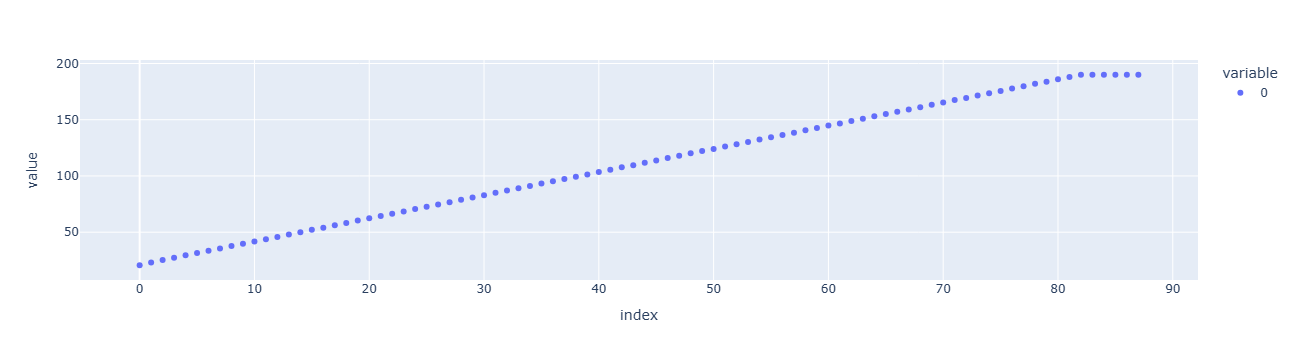

In [350]:
T = Cu_05_heat.get_T_profile()
px.scatter(T)

In [351]:
Time = Cu_05_iso.get_Time_profile()
Time[5] + 62

np.int64(231)

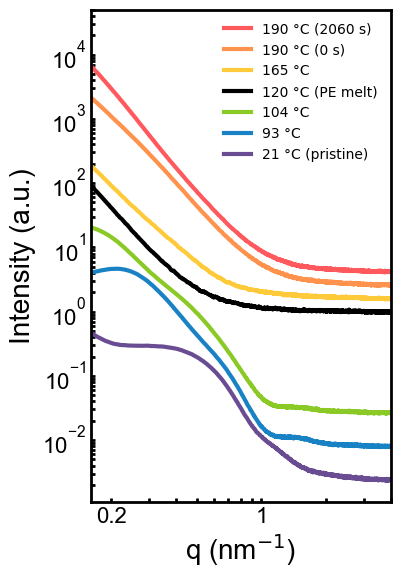

In [356]:
fig_a, ax_a = plt.subplots(figsize=(4, 6))

coef = 0.3
linewidth = 3

# Данные и параметры: (массив, сдвиг, цвет, метка)
plots_data_a = [
    (I_array_iso[-1], -1.2, '#ff595e', '190 °C (2060 s)'),
    (I_array_heat[-1], -0.8, '#ff924c', '190 °C (0 s)'),
    (I_array_heat[70], -0.4, '#ffca3a', '165 °C'),
    (I_array_heat[48], 0, 'black', '120 °C (PE melt)'),
    (I_array_heat[40], 3, '#8ac926', '104 °C'),
    (I_array_heat[35], 4, '#1982c4', '93 °C'),
    (I_array_heat[0], 5, '#6a4c93', '21 °C (pristine)')
]

for data, exp, color, label in plots_data_a:
    ax_a.loglog(q, data * coef ** exp, linewidth=linewidth, color=color, label=label)

ax_a.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax_a.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax_a.set_xlim(0.16, 4)
ax_a.set_ylim(1.1e-3, 5e4)
ax_a.set_xticks([0.2, 1])
ax_a.set_xticklabels(['0.2', '1'])

ax_a.legend(fontsize=10, frameon=False)
ax_a.tick_params(axis="both", which='both', direction="in", width=2, length=3, labelsize=16)

for axis in ['top','bottom','left','right']:
    ax_a.spines[axis].set_linewidth(2)

for tick in ax_a.get_xticklabels() + ax_a.get_yticklabels():
    tick.set_fontfamily('Arial')

# Устанавливаем положение осей: bottom = 0.12, height = 0.82
ax_a.set_position([0.15, 0.12, 0.75, 0.82])

plt.savefig(r'E:\Nps Cu\Figures v2\Fig1_a.png', dpi=300, bbox_inches='tight', transparent=True)
# plt.close(fig_a)

### Fig1b: WAXS curves

In [316]:
q, I_array_heat = Cu_05_heat.integrate1d_WAXS(ai_waxs, 10000, mask = img_mask_waxs)
# norm_saxs(q, I_array_heat)

q, I_array_iso = Cu_05_iso.integrate1d_WAXS(ai_waxs, 10000, mask = img_mask_waxs)
# norm_saxs(q, I_array_iso)
theta_111 = np.array([43.34, 38.86, 36.33]) /2

q_111 = 4 * pi * np.sin(np.deg2rad(theta_111)) / 0.15406 

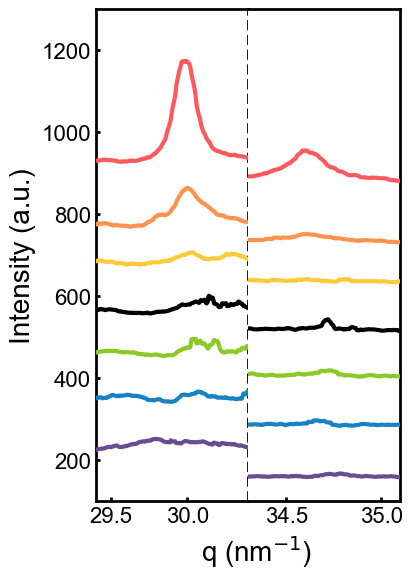

In [317]:
fig_b, (ax1, ax2) = plt.subplots(1, 2, figsize=(4, 6), sharey=True)

K = 120
linewidth = 3

plots_data_b = [
    (I_array_iso[-1], 6, '#ff595e', '190 °C (2060 s)', 10),
    (I_array_iso[1], 5, '#ff924c', '190 °C (0 s)', 9),
    (I_array_heat[70], 4, '#ffca3a', '165 °C', 8),
    (I_array_heat[49], 3, 'black', '120 °C (PE melt)', 7),
    (I_array_heat[41], 2, '#8ac926', '104 °C', 6),
    (I_array_heat[35], 1, '#1982c4', '93 °C', 5),
    (I_array_heat[12], 0, '#6a4c93', '21 °C (pristine)', 3)
]

xlims = [(29.4, 30.4), (34.3, 35.1)]

for ax, xlim in zip([ax1, ax2], xlims):
    for data, offset, color, label, zorder in plots_data_b:
        ax.plot(q, data + K * offset, linewidth=linewidth, color=color, label=label, zorder=zorder)
    
    ax.set_xlim(xlim)
    ax.set_ylim(100, 1300)
    
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    
    ax.tick_params(axis="both", which='both', direction="in", width=2, length=3, labelsize=16)
    
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial')

ax1.set_ylabel('Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax2.set_ylabel('')

# Убираем y-тики на втором графике
ax2.tick_params(axis='y', left=False, labelleft=False)

# Убираем внутренние границы и склеиваем
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Вертикальная линия на первом графике
ax1.axvline(x=30.4, color='black', linewidth=2, linestyle='--')

# Общая подпись оси x
fig_b.text(0.5, 0.02, r'q (nm$^{-1}$)', ha='center', fontsize=20, fontfamily='Arial')

# Склеиваем сабплоты
plt.subplots_adjust(wspace=0)

# Устанавливаем положение осей с теми же bottom и height, что и у графика a
# left и width подбираем для двух сабплотов
ax1.set_position([0.10, 0.12, 0.38, 0.82])
ax2.set_position([0.48, 0.12, 0.38, 0.82])

plt.savefig(r'E:\Nps Cu\Figures v2\Fig1_b.png', dpi=300, bbox_inches='tight', transparent=True)
# plt.close(fig_b)

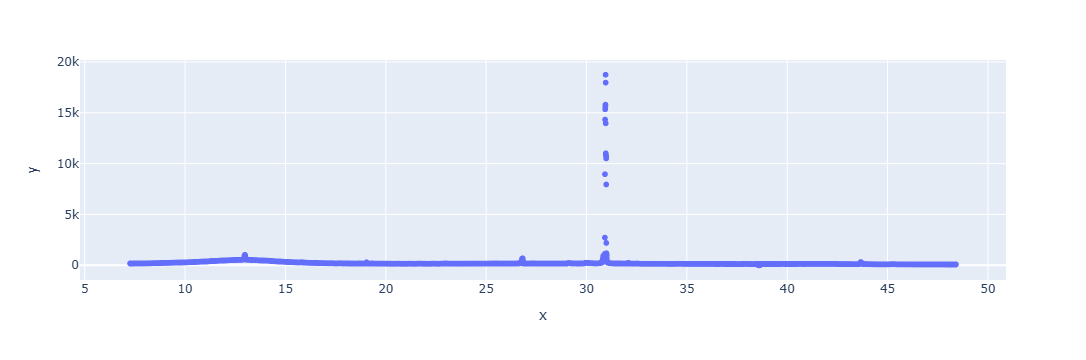

In [231]:
px.scatter(x=q, y=I_array_iso[0])

### Fig2a: SAXS after bkg subraction

In [450]:
import scipy
def Spheres(x, scale, Ravg, p, bkg):
    global sigma
    sigma = p*Ravg
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2)
        Iq.append(scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1])
    Iq = np.array(Iq)
    Iq /= max(Iq)
    return scale * Iq + bkg

In [353]:
q, I_array_heat = Cu_05_heat.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_heat)
# px.scatter(Cu_05_heat.get_T_profile()
q, I_array_iso = Cu_05_iso.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_iso)

In [461]:
Cu_05_heat.get_T_profile()[66]

Found 88 EDF files in SAXS


np.float64(157.0)

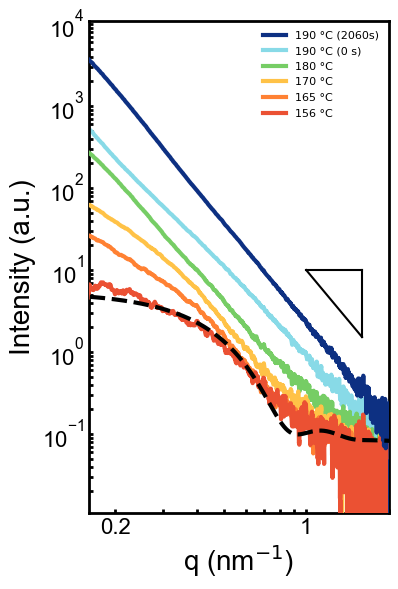

In [579]:
fig_a, ax_a = plt.subplots(figsize=(4, 6))

coef = 1.2
linewidth = 3

bkg = I_array_heat[45]
# Данные и параметры: (массив, сдвиг, цвет, метка)
plots_data_a = [

    (I_array_iso[-1] - 1 * bkg, 5, '#0d3082', '190 °C (2060s)', 10, 3),
    (I_array_heat[82] - 1 * bkg, 4, '#88dae7', '190 °C (0 s)', 2, 3),
    (I_array_heat[77] - 1 * bkg, 3, '#76cd65', '180 °C', 3, 3),
    # (I_array_heat[74] - 1 * bkg, 3, '#f29222', '174 °C', 4, 3),
    (I_array_heat[72] - 1 * bkg, 2, '#ffc247', '170 °C', 5, 3),
    (I_array_heat[70] - 1 * bkg, 1, '#ff8133', '165 °C', 6, 3),
    (I_array_heat[65] + I_array_heat[66] - 2 * bkg, 0, '#eb5133', '156 °C', 6, 3),
]

for data, exp, color, label, zorder, linewidth in plots_data_a:
    ax_a.loglog(q, data * coef ** exp , linewidth=linewidth, color=color, label=label, zorder=zorder)

ax_a.set_xlabel(r'q (nm$^{-1}$)', fontsize=20, fontfamily='Arial')
ax_a.set_ylabel(r'Intensity (a.u.)', fontsize=20, fontfamily='Arial')
ax_a.set_xlim(0.16, 2)
ax_a.set_ylim(1.1e-2, 1.1e4)
ax_a.set_xticks([0.2, 1])
ax_a.set_xticklabels(['0.2', '1'])

ax_a.legend(fontsize=8, frameon=False)
ax_a.tick_params(axis="both", which='both', direction="in", width=2, length=3, labelsize=16)

for axis in ['top','bottom','left','right']:
    ax_a.spines[axis].set_linewidth(2)

for tick in ax_a.get_xticklabels() + ax_a.get_yticklabels():
    tick.set_fontfamily('Arial')

# Устанавливаем положение осей: bottom = 0.12, height = 0.82
ax_a.set_position([0.15, 0.12, 0.75, 0.82])


plt.plot(q, Spheres(q, 5, 4.8, 0.11, 0.8e-1), color='black', label='Form-factor', linewidth=3, linestyle='--', zorder=30)

x_porod = np.linspace(1.0, 1.6, 1000)
y_porod = x_porod ** -4
y_porod /= max(y_porod)
A = 1e1
plt.plot(x_porod, y_porod * A, color='black', )
plt.plot(x_porod, A * np.ones(1000), color='black', )
plt.plot(np.ones(1000)*max(x_porod), y_porod * A, color='black', )



plt.savefig(r'E:\Nps Cu\Figures v2\Fig2_a.png', dpi=300, bbox_inches='tight', transparent=True)
# plt.close(fig_a)

### Fig2b: Invariant Rg 111 peak ...

In [644]:
q, I_array_heat = Cu_3_heat.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_heat)
# px.scatter(Cu_05_heat.get_T_profile()
q, I_array_iso = Cu_3_iso.integrate1d_SAXS(ai_saxs, 10000, mask = img_mask_saxs)
norm_saxs(q, I_array_iso)

In [625]:
def power(x, A, p):
    return A * np.power(x, p)

In [645]:
bkg = I_array_heat[45]

res1_heat = []
res2_heat = []
res3_heat = []

for i in range(62, 82):
    
    x, y = q, I_array_heat[i] - bkg
    limit = .5
    res1_heat.append(np.trapezoid(y[(x > 0.16) * (x < 2)] * x[(x > 0.16) * (x < 2)] ** 2, x[(x > 0.16) * (x < 2)]))
    res2_heat.append(np.trapezoid(y[(x > 0.16) * (x < limit)] * x[(x > 0.16) * (x < limit)] ** 2, x[(x > 0.16) * (x < limit)]))
    res3_heat.append(np.trapezoid(y[(x > limit) * (x < 2)] * x[(x > limit) * (x < 2)]  ** 2, x[(x > limit) * (x < 2)] ))

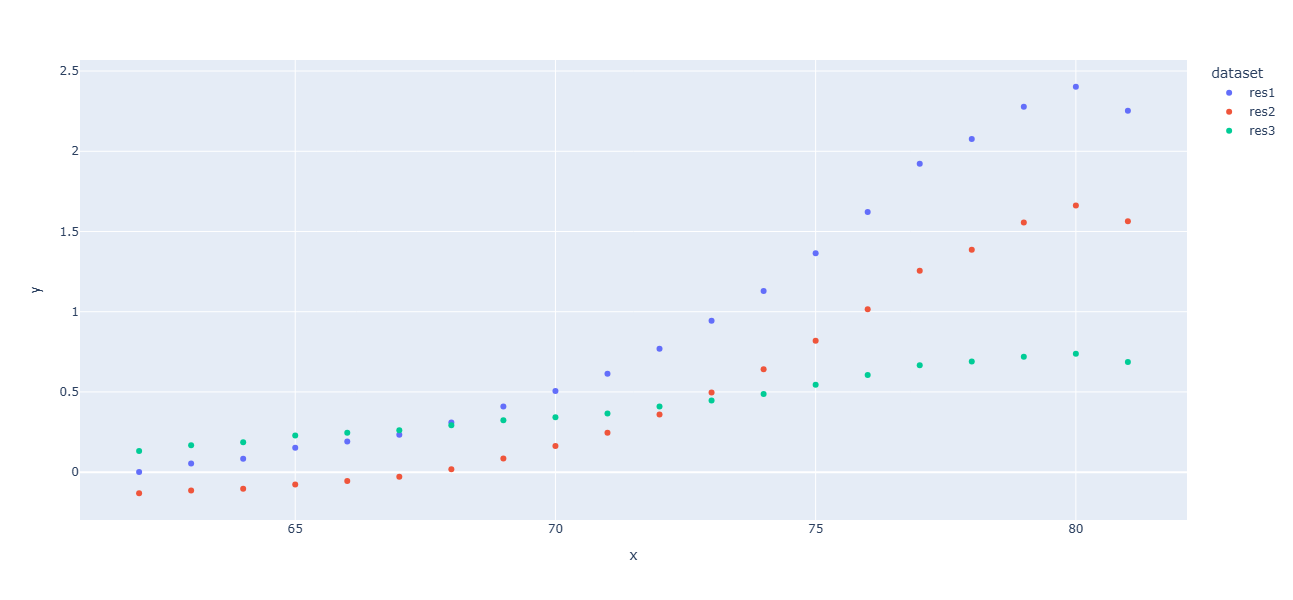

In [646]:
import plotly.express as px
import pandas as pd

# Создаем DataFrame для удобства
df = pd.DataFrame({
    'x': list(range(62, 82)) * 3,
    'y': list(res1_heat) + list(res2_heat) + list(res3_heat),
    'dataset': ['res1'] * len(res1_heat) + ['res2'] * len(res2_heat) + ['res3'] * len(res3_heat)
})

fig = px.scatter(df, x='x', y='y', color='dataset', 
                 width=600, height=600)  # Квадратная фигура 600x600
fig.show()

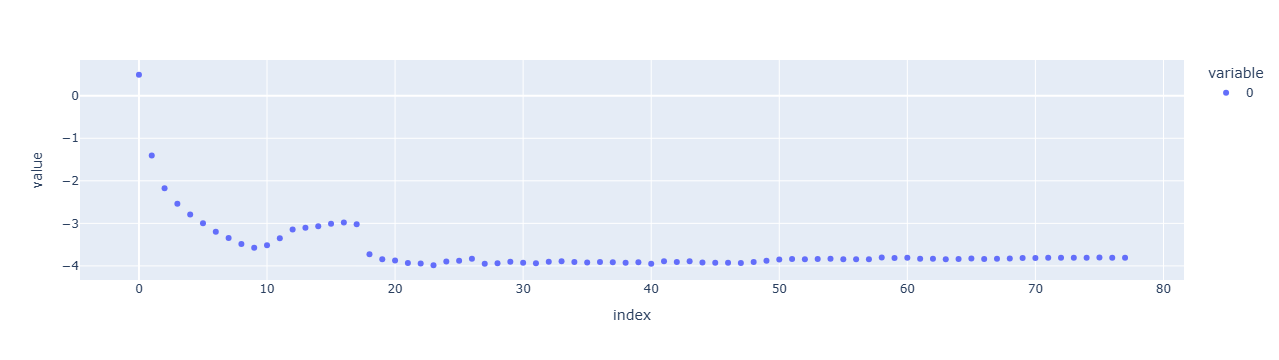

In [650]:
power_heat = []
for i in range(70, 88):
    x, y = q, I_array_heat[i] - bkg
    p, cov = curve_fit(power, x[(x > 0.18) * (x < 0.25)], y[(x > 0.18) * (x < 0.25)])
    power_heat.append(p[1])
    
for i in range(len(I_array_iso)):
    x, y = q, I_array_iso[i] - bkg
    p, cov = curve_fit(Spower, x[(x > 0.18) * (x < 0.25)], y[(x > 0.18) * (x < 0.25)])
    power_heat.append(p[1])
px.scatter(power_heat)

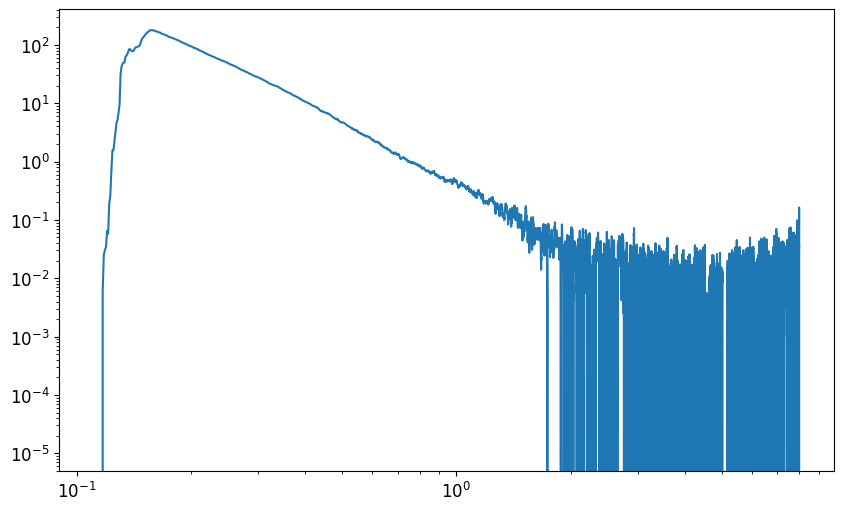

In [649]:
plt.loglog(q, I_array_heat[75] - 1 * bkg)